# Notebook 10 — Leuven Totem Case Study
Deep-dive into the #1 volume station in the AWV network,
examining how KU Leuven's academic calendar interacts with
weather to shape cycling demand.

## 0. Imports & Load

In [22]:
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [23]:
%matplotlib inline
plt.rcParams["figure.dpi"] = 120

ROOT      = Path().resolve().parent
PROCESSED = ROOT / "data" / "processed"
FIGS      = ROOT / "outputs" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

KU_COLORS = {
    "teaching"  : "#C8E6C9",
    "exam"      : "#FFCDD2",
    "exam_prep" : "#FFF9C4",
    "recess"    : "#EEEEEE",
}
KU_ORDER  = ["teaching", "exam_prep", "exam", "recess"]
KU_LABELS = ["Teaching", "Exam prep", "Exam", "Recess"]
KU_BAR_COLORS = ["#4CAF50", "#FFC107", "#F44336", "#9E9E9E"]

def shade_ku_periods(ax, df):
    """Shade plot background by KU Leuven academic period."""
    for period, color in KU_COLORS.items():
        mask = df["ku_leuven_period"] == period
        if not mask.any():
            continue
        dates = df[mask]["date"].sort_values()
        start = dates.iloc[0]
        prev  = start
        for d in dates.iloc[1:]:
            if (d - prev).days > 1:
                ax.axvspan(start, prev + pd.Timedelta(days=1),
                           color=color, alpha=0.5, lw=0)
                start = d
            prev = d
        ax.axvspan(start, prev + pd.Timedelta(days=1),
                   color=color, alpha=0.5, lw=0)

panel      = pd.read_parquet(PROCESSED / "analysis_panel.parquet")
site_cls   = pd.read_parquet(PROCESSED / "site_classification.parquet")
panel = panel.merge(
    site_cls[["site ID", "site_type", "commute_score"]],
    on="site ID", how="left"
)
resilience = pd.read_parquet(PROCESSED / "station_resilience.parquet")

leuven = panel[panel["site ID"] == 107].copy()
leuven["date"] = pd.to_datetime(leuven["date"])
leuven = leuven.sort_values("date").reset_index(drop=True)

panel_good = panel[panel["low_coverage"] == False].copy()
panel_good["date"] = pd.to_datetime(panel_good["date"])

lt_res = resilience[resilience["site ID"] == 107].iloc[0]

print("=== Leuven Totem Basic Stats ===")
print(f"Date range   : {leuven['date'].min().date()} \u2192 {leuven['date'].max().date()}")
print(f"Total rows   : {len(leuven)}, NaN count: {leuven['aantal'].isna().sum()}")
print(f"Avg daily    : {leuven['aantal'].mean():.0f}")
print(f"Max daily    : {leuven['aantal'].max():.0f} "
      f"(date: {leuven.loc[leuven['aantal'].idxmax(), 'date'].date()})")
print(f"Min daily    : {leuven['aantal'].min():.0f} "
      f"(date: {leuven.loc[leuven['aantal'].idxmin(), 'date'].date()})")
print(f"site_type    : {leuven['site_type'].iloc[0]}")
print(f"commute_score: {leuven['commute_score'].iloc[0]:.3f}")
print(f"Resilience   : {lt_res['resilience_score']:.3f} "
      f"(rank #{int(lt_res['sensitivity_rank'])}/132)")
print(f"Priority rank: #{int(lt_res['priority_rank'])}/132")


=== Leuven Totem Basic Stats ===
Date range   : 2023-01-01 → 2025-12-31
Total rows   : 1096, NaN count: 0
Avg daily    : 4425
Max daily    : 8432 (date: 2025-04-12)
Min daily    : 631 (date: 2023-12-25)
site_type    : mixed
commute_score: 0.395
Resilience   : 0.741 (rank #119/132)
Priority rank: #62/132


## 1. Full Time Series Overview

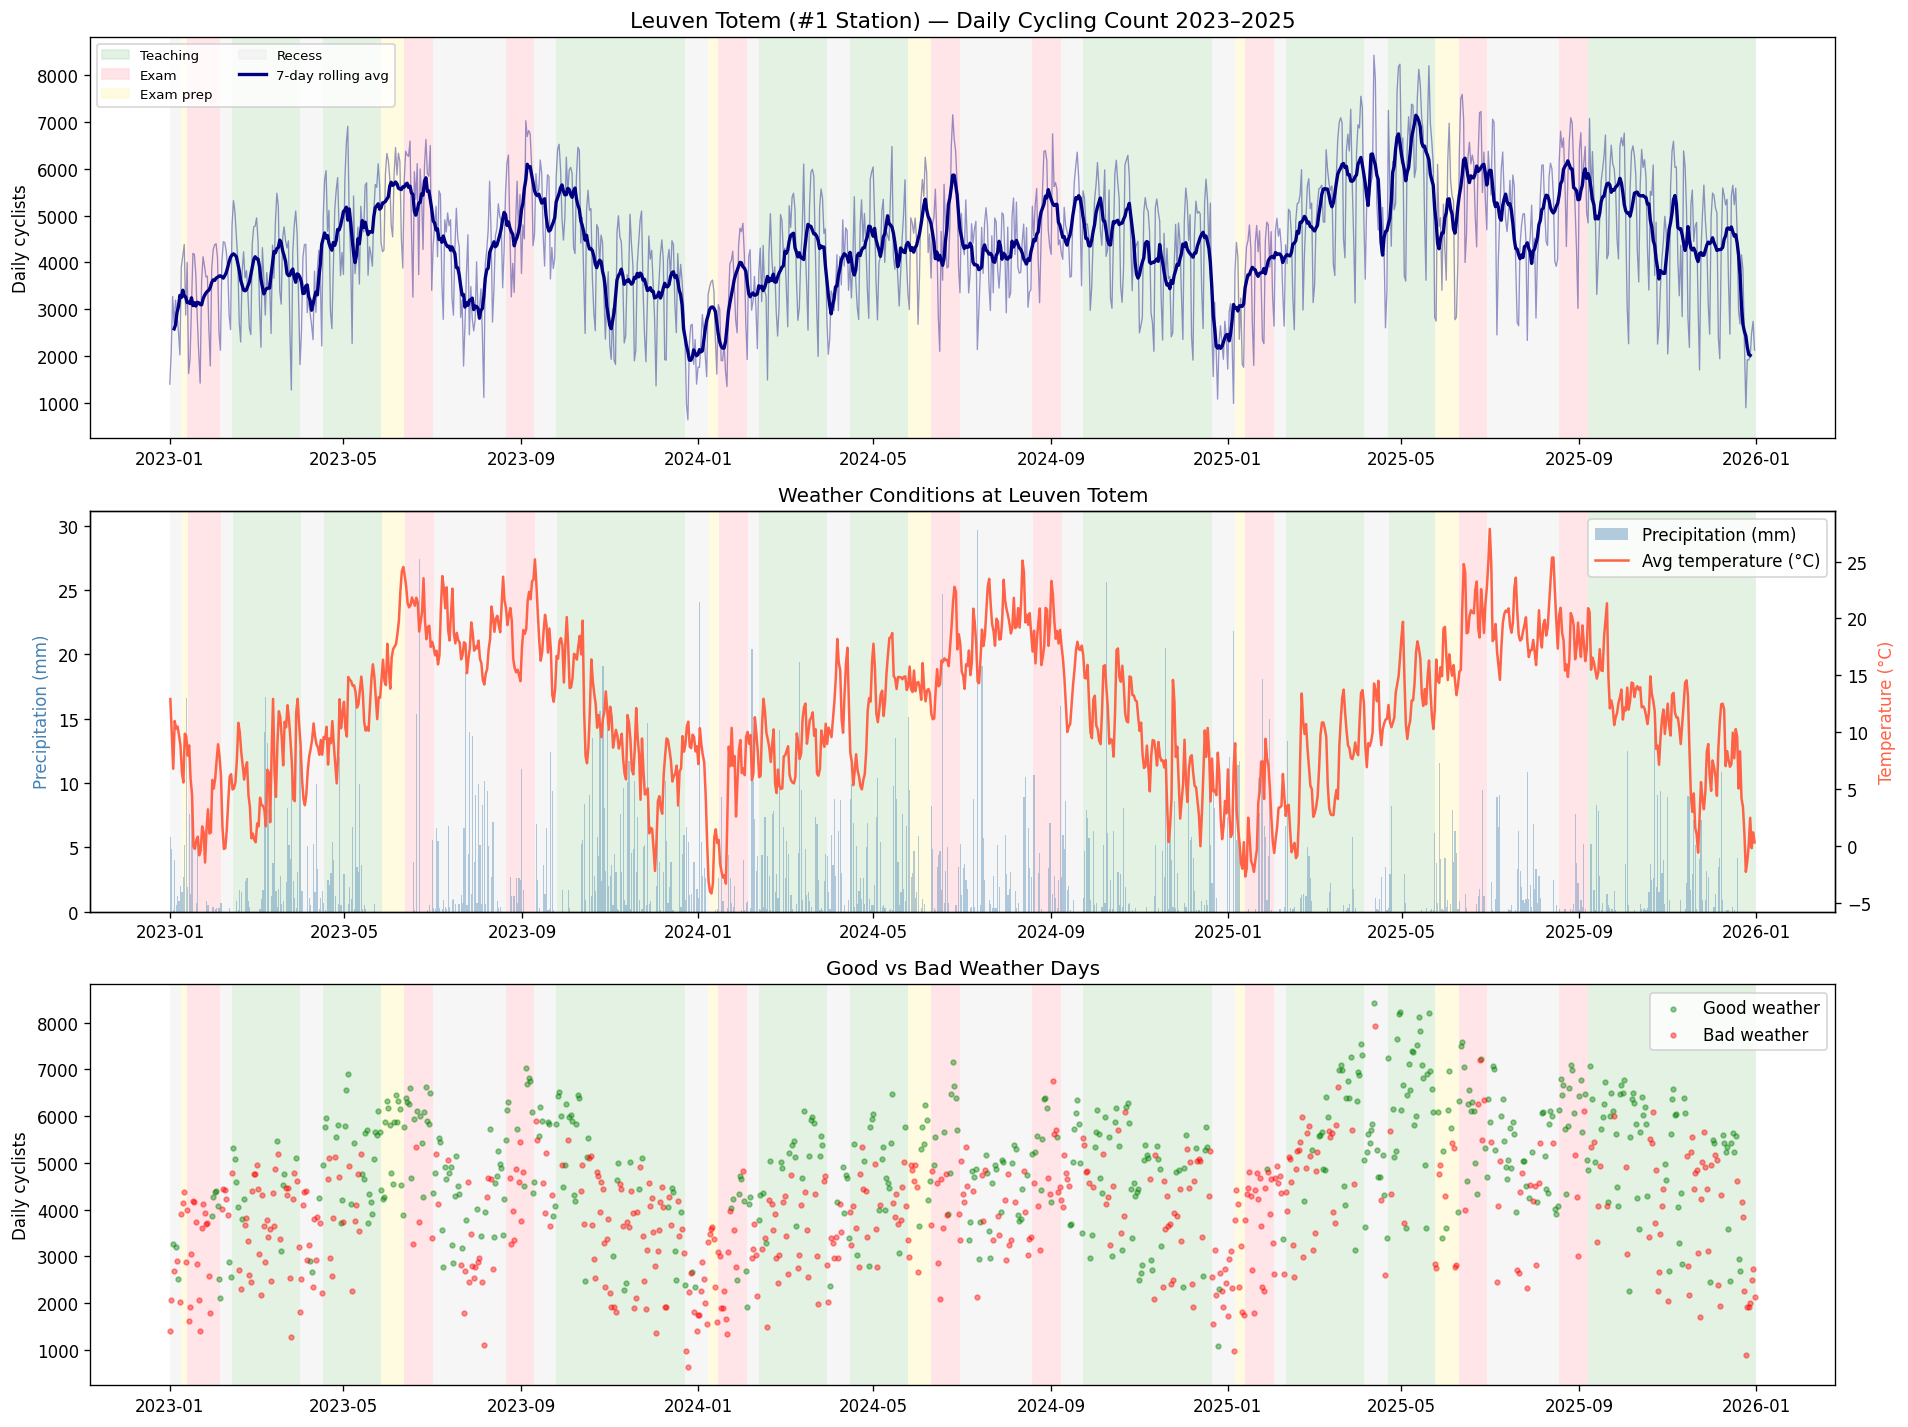

10_leuven_totem_overview saved.


In [24]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

legend_patches = [
    mpatches.Patch(color=c, alpha=0.5, label=p.replace('_', ' ').capitalize())
    for p, c in KU_COLORS.items()
]

# Panel A: raw daily count + 7-day rolling avg
ax = axes[0]
shade_ku_periods(ax, leuven)
ax.plot(leuven["date"], leuven["aantal"],
        color="navy", alpha=0.4, linewidth=0.8)
rolling7 = leuven.set_index("date")["aantal"].rolling(7, center=True).mean()
ax.plot(rolling7.index, rolling7.values,
        color="navy", linewidth=2, label="7-day rolling avg")
ax.set_ylabel("Daily cyclists")
ax.set_title("Leuven Totem (#1 Station) \u2014 Daily Cycling Count 2023\u20132025",
             fontsize=13)
ax.legend(handles=legend_patches + ax.get_legend_handles_labels()[0],
          loc="upper left", fontsize=8, ncol=2)

# Panel B: temperature + precipitation overlay
ax = axes[1]
shade_ku_periods(ax, leuven)
ax2 = ax.twinx()
ax.bar(leuven["date"], leuven["precip_total"],
       color="steelblue", alpha=0.4, label="Precipitation (mm)")
ax2.plot(leuven["date"], leuven["temp_avg"],
         color="tomato", linewidth=1.5, label="Avg temperature (\u00b0C)")
ax.set_ylabel("Precipitation (mm)", color="steelblue")
ax2.set_ylabel("Temperature (\u00b0C)", color="tomato")
ax.set_title("Weather Conditions at Leuven Totem")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

# Panel C: good vs bad weather days scatter
ax = axes[2]
shade_ku_periods(ax, leuven)
good_days = leuven[leuven["is_bad_weather"] == False]
bad_days  = leuven[leuven["is_bad_weather"] == True]
ax.scatter(good_days["date"], good_days["aantal"],
           color="green", alpha=0.4, s=8, label="Good weather")
ax.scatter(bad_days["date"],  bad_days["aantal"],
           color="red",   alpha=0.4, s=8, label="Bad weather")
ax.set_ylabel("Daily cyclists")
ax.set_title("Good vs Bad Weather Days")
ax.legend(loc="upper right")

fig.tight_layout()
fig.savefig(FIGS / "10_leuven_totem_overview.png", dpi=150)
plt.show()
print("10_leuven_totem_overview saved.")

## 2. Academic Period Analysis

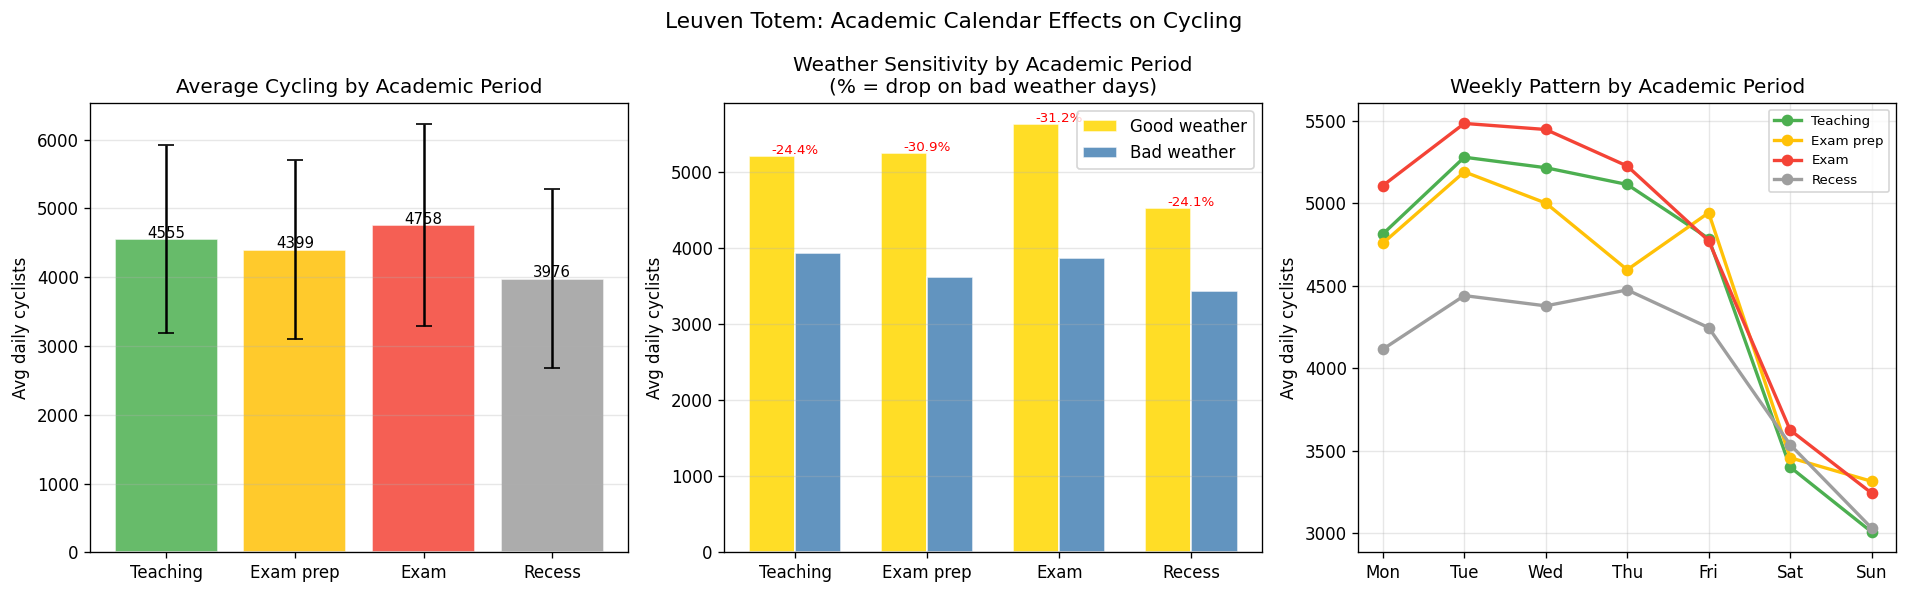

10_leuven_academic_effects saved.


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel A: avg daily cycling by KU period
ax = axes[0]
avgs = [leuven[leuven["ku_leuven_period"] == p]["aantal"].mean() for p in KU_ORDER]
stds = [leuven[leuven["ku_leuven_period"] == p]["aantal"].std()  for p in KU_ORDER]
bars = ax.bar(KU_LABELS, avgs, color=KU_BAR_COLORS, alpha=0.85, edgecolor="white")
ax.errorbar(KU_LABELS, avgs, yerr=stds, fmt="none", color="black", capsize=5)
for bar, val in zip(bars, avgs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 20,
            f"{val:.0f}", ha="center", fontsize=9)
ax.set_ylabel("Avg daily cyclists")
ax.set_title("Average Cycling by Academic Period")
ax.grid(axis="y", alpha=0.3)

# Panel B: weather sensitivity per KU period
ax = axes[1]
drops_good, drops_bad = [], []
for p in KU_ORDER:
    sub = leuven[leuven["ku_leuven_period"] == p]
    drops_good.append(sub[sub["is_bad_weather"] == False]["aantal"].mean())
    drops_bad.append(sub[sub["is_bad_weather"] == True]["aantal"].mean())

x = np.arange(len(KU_ORDER))
w = 0.35
ax.bar(x - w/2, drops_good, w, label="Good weather",
       color="gold", alpha=0.85, edgecolor="white")
ax.bar(x + w/2, drops_bad,  w, label="Bad weather",
       color="steelblue", alpha=0.85, edgecolor="white")
for i, (g, b) in enumerate(zip(drops_good, drops_bad)):
    drop = (b - g) / g * 100
    ax.text(x[i], max(g, b) + 30, f"{drop:.1f}%",
            ha="center", fontsize=8, color="red")
ax.set_xticks(x)
ax.set_xticklabels(KU_LABELS)
ax.set_ylabel("Avg daily cyclists")
ax.set_title("Weather Sensitivity by Academic Period\n"
             "(% = drop on bad weather days)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

# Panel C: day-of-week pattern by KU period
ax = axes[2]
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
for period, color in zip(KU_ORDER, KU_BAR_COLORS):
    sub = leuven[leuven["ku_leuven_period"] == period]
    dow_avg = sub.groupby("dayofweek")["aantal"].mean()
    ax.plot(dow_labels, dow_avg.values,
            marker="o", label=period.replace("_", " ").capitalize(),
            color=color, linewidth=2)
ax.set_ylabel("Avg daily cyclists")
ax.set_title("Weekly Pattern by Academic Period")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

fig.suptitle("Leuven Totem: Academic Calendar Effects on Cycling",
             fontsize=13)
fig.tight_layout()
fig.savefig(FIGS / "10_leuven_academic_effects.png", dpi=150)
plt.show()
print("10_leuven_academic_effects saved.")

## 3. Weather × Academic Period Interaction 

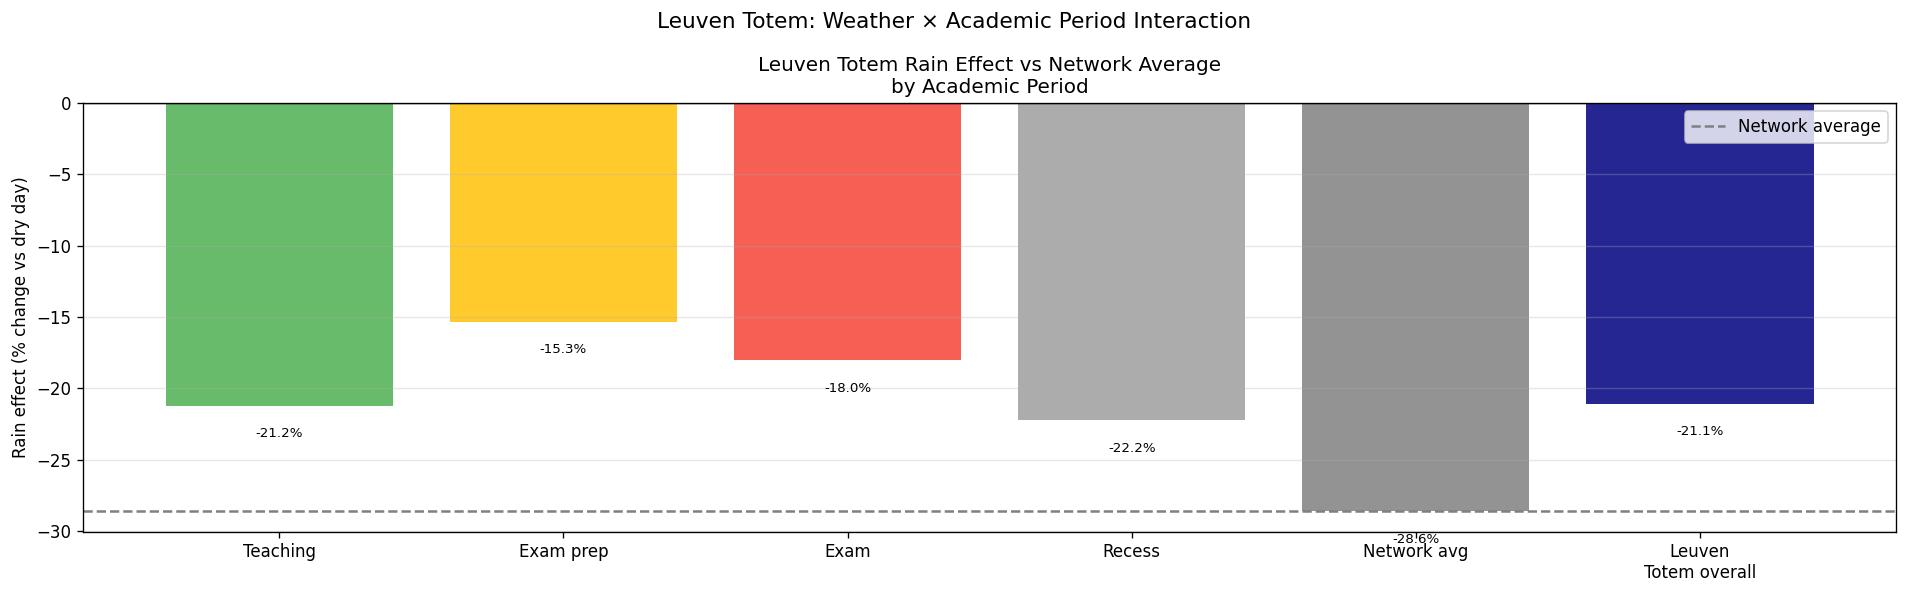

10_weather_academic_interaction saved.
Leuven overall cold effect : -19.9%
Network overall cold effect: -32.7%


In [35]:
rain_effects = {}
cold_effects = {}
for p in KU_ORDER:
    sub  = leuven[leuven["ku_leuven_period"] == p]
    dry  = sub[sub["is_rainy_day"] == False]["aantal"].mean()
    rain = sub[sub["is_rainy_day"] == True]["aantal"].mean()
    mild = sub[sub["is_cold_day"]  == False]["aantal"].mean()
    cold = sub[sub["is_cold_day"]  == True]["aantal"].mean()
    rain_effects[p] = (rain - dry)  / dry  * 100
    cold_effects[p] = (cold - mild) / mild * 100

network_dry  = panel_good[panel_good["is_rainy_day"] == False]["aantal"].mean()
network_rain = panel_good[panel_good["is_rainy_day"] == True]["aantal"].mean()
network_rain_effect = (network_rain - network_dry) / network_dry * 100

lt_dry  = leuven[leuven["is_rainy_day"] == False]["aantal"].mean()
lt_rain = leuven[leuven["is_rainy_day"] == True]["aantal"].mean()
lt_rain_effect = (lt_rain - lt_dry) / lt_dry * 100

fig, ax = plt.subplots(1, 1, figsize=(16, 5))

#  per-period rain effect vs network average

categories = KU_LABELS + ["Network avg", "Leuven\nTotem overall"]
values     = rain_vals  + [network_rain_effect, lt_rain_effect]
colors_bar = KU_BAR_COLORS + ["gray", "navy"]
bars = ax.bar(categories, values, color=colors_bar, alpha=0.85)
ax.axhline(network_rain_effect, color="gray",
           linestyle="--", linewidth=1.5, label="Network average")
ax.axhline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val - 1.5 if val < 0 else val + 0.5,
            f"{val:.1f}%", ha="center", va="top", fontsize=8)
ax.set_ylabel("Rain effect (% change vs dry day)")
ax.set_title("Leuven Totem Rain Effect vs Network Average\n"
             "by Academic Period")
ax.legend()
ax.grid(axis="y", alpha=0.3)

fig.suptitle("Leuven Totem: Weather \u00d7 Academic Period Interaction",
             fontsize=13)
fig.tight_layout()
fig.savefig(FIGS / "10_weather_academic_interaction.png", dpi=150)
plt.show()
print("10_weather_academic_interaction saved.")

# overall cold effect
lt_mild = leuven[leuven["is_cold_day"] == False]["aantal"].mean()
lt_cold = leuven[leuven["is_cold_day"] == True]["aantal"].mean()
lt_cold_effect = (lt_cold - lt_mild) / lt_mild * 100

network_mild = panel_good[panel_good["is_cold_day"] == False]["aantal"].mean()
network_cold = panel_good[panel_good["is_cold_day"] == True]["aantal"].mean()
network_cold_effect = (network_cold - network_mild) / network_mild * 100

print(f"Leuven overall cold effect : {lt_cold_effect:.1f}%")
print(f"Network overall cold effect: {network_cold_effect:.1f}%")

## 4. Leuven Totem vs Comparable Stations

Comparable high-volume stations:
                  naam    gemeente site_type      aantal
          leuven totem      Leuven     mixed 4424.546387
       Leuven teller 1      Leuven  commuter 2328.721680
   Nieuwpoort teller 1  Nieuwpoort   leisure 2145.483643
Hasselt-Kempische brug     Hasselt     mixed 1992.618652
          Hasselt ring     Hasselt   leisure 1974.110840
Hasselt-Kempische brug     Hasselt   leisure 1925.150757
                 Zemst       Zemst  commuter 1693.276245
     Dendermonde totem Dendermonde     mixed 1599.478149


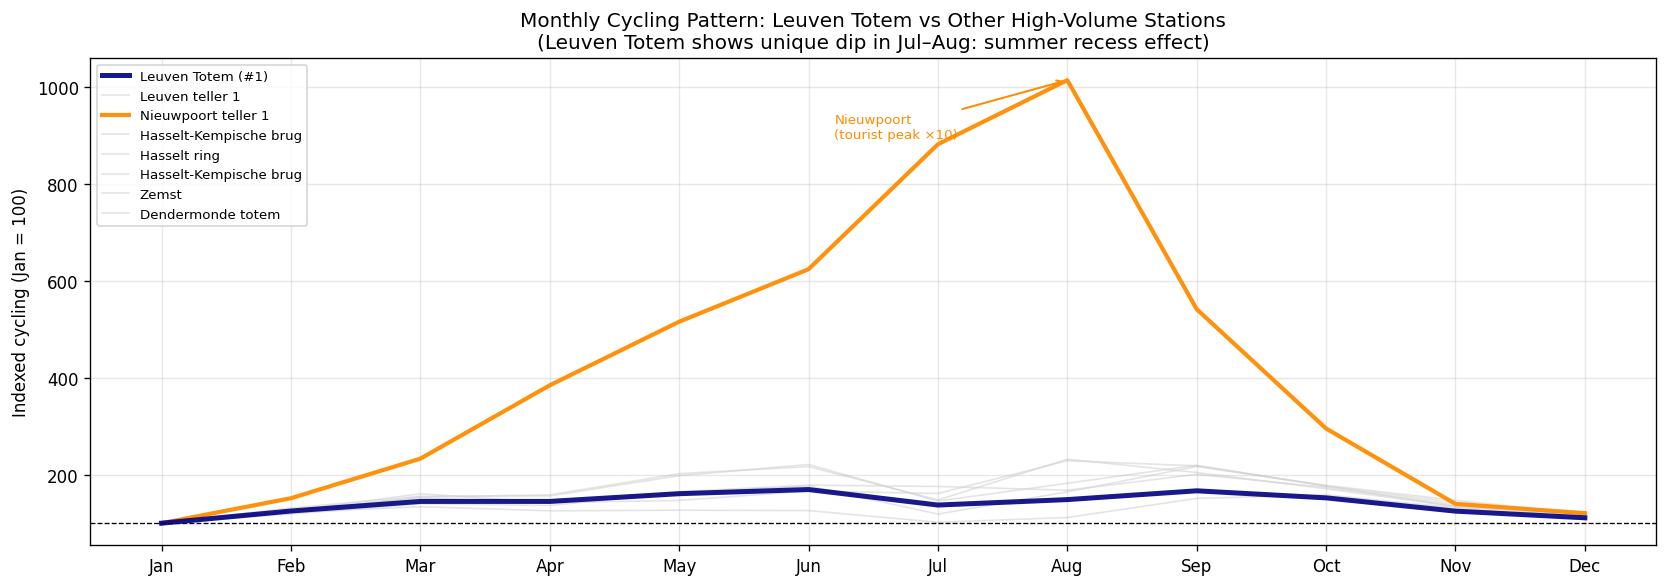

10_leuven_vs_comparable saved.


In [29]:
comparable = panel_good[
    panel_good.groupby("site ID")["aantal"].transform("mean") > 1000
].copy()
top_sites = (
    comparable.groupby(["site ID", "naam", "gemeente", "site_type"])["aantal"]
    .mean()
    .reset_index()
    .sort_values("aantal", ascending=False)
    .head(8)
)
print("Comparable high-volume stations:")
print(top_sites[["naam", "gemeente", "site_type", "aantal"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 5))

for _, row in top_sites.iterrows():
    site_data    = panel_good[panel_good["site ID"] == row["site ID"]]
    monthly      = site_data.groupby("month")["aantal"].mean()
    monthly_norm = monthly / monthly.iloc[0] * 100 if monthly.iloc[0] > 0 else monthly
    is_leuven    = row["site ID"] == 107
    is_nieuwpoort = "nieuwpoort" in str(row["gemeente"]).lower() or \
                    "nieuwpoort" in str(row["naam"]).lower()

    if is_leuven:
        color, lw, alpha, zorder = "navy", 3, 0.9, 3
        label = "Leuven Totem (#1)"
    elif is_nieuwpoort:
        color, lw, alpha, zorder = "darkorange", 2.5, 0.95, 2
        label = f"{row['naam']}"
    else:
        color, lw, alpha, zorder = "lightgray", 1, 0.6, 1
        label = row["naam"]

    ax.plot(
        range(1, 13), monthly_norm.values,
        color=color, linewidth=lw, alpha=alpha, zorder=zorder,
        label=label,
    )

    # annotate Nieuwpoort peak month
    if is_nieuwpoort:
        peak_month = monthly_norm.values.argmax() + 1
        peak_val   = monthly_norm.values.max()
        ax.annotate(
            f"Nieuwpoort\n(tourist peak ×{peak_val/100:.0f})",
            xy=(peak_month, peak_val),
            xytext=(peak_month - 1.8, peak_val - 120),
            fontsize=8, color="darkorange",
            arrowprops=dict(arrowstyle="->", color="darkorange", lw=1.2),
        )

ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                     "Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_ylabel("Indexed cycling (Jan = 100)")
ax.set_title(
    "Monthly Cycling Pattern: Leuven Totem vs Other High-Volume Stations\n"
    "(Leuven Totem shows unique dip in Jul–Aug: summer recess effect)"
)
ax.axhline(100, color="black", linestyle="--", linewidth=0.8)
ax.legend(fontsize=8, loc="upper left")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGS / "10_leuven_vs_comparable.png", dpi=150)
plt.show()
print("10_leuven_vs_comparable saved.")

## 5. Validation: Why Exam Prep Rain Effect Appears Muted

In [30]:
# ── Validation: exam_prep rain effect ───────────────────────────

# 1. Sample sizes per period × rain condition
print('=== 1. Sample sizes (rainy vs dry days per period) ===')
for p in KU_ORDER:
    sub  = leuven[leuven['ku_leuven_period'] == p]
    n_dry  = (sub['is_rainy_day'] == False).sum()
    n_rain = (sub['is_rainy_day'] == True).sum()
    print(f'  {p:12s}: {n_dry:3d} dry, {n_rain:3d} rainy')

# 2. Month distribution inside exam_prep
print('\n=== 2. Month distribution within exam_prep ===')
ep = leuven[leuven['ku_leuven_period'] == 'exam_prep']
print(ep.groupby('month')['aantal'].agg(['count', 'mean']).rename(
    columns={'count': 'n_days', 'mean': 'avg_count'}))

# 3. Compare exam_prep rain effect: Leuven vs entire network
print('\n=== 3. Network-wide rain effect during exam_prep ===')
ep_net   = panel_good[panel_good['ku_leuven_period'] == 'exam_prep']
ep_dry_n = ep_net[ep_net['is_rainy_day'] == False]['aantal'].mean()
ep_rain_n= ep_net[ep_net['is_rainy_day'] == True]['aantal'].mean()
ep_net_effect = (ep_rain_n - ep_dry_n) / ep_dry_n * 100
print(f'  Network avg during exam_prep: {ep_net_effect:+.1f}%')
print(f'  Leuven Totem during exam_prep: {rain_effects["exam_prep"]:+.1f}%')
print(f'  Network overall rain effect  : {network_rain_effect:+.1f}%')

# 4. Month-matched rain effect (compare rainy vs dry within same months)
print('\n=== 4. Month-matched rain effect (May & Jun only) ===')
for month_num, month_name in [(5, 'May'), (6, 'Jun')]:
    sub   = leuven[leuven['month'] == month_num]
    dry_m = sub[sub['is_rainy_day'] == False]['aantal'].mean()
    rain_m= sub[sub['is_rainy_day'] == True]['aantal'].mean()
    if dry_m > 0:
        eff = (rain_m - dry_m) / dry_m * 100
        print(f'  {month_name}: dry={dry_m:.0f}, rain={rain_m:.0f}, effect={eff:+.1f}%')
    else:
        print(f'  {month_name}: no dry days')

# 5. Verdict
print('\n=== 5. Validation verdict ===')
ep_n_rainy = (ep['is_rainy_day'] == True).sum()
if ep_n_rainy < 15:
    print(f'  WARNING: only {ep_n_rainy} rainy days in exam_prep — estimate unreliable.')
else:
    print(f'  OK: {ep_n_rainy} rainy days in exam_prep.')
if abs(ep_net_effect) < abs(network_rain_effect) * 0.6:
    print('  FINDING: network-wide exam_prep rain effect is also muted vs annual avg,'
          '\n           suggesting seasonal confounding (May–Jun dry/warm baseline),'
          '\n           not a Leuven-specific resilience signal.')
else:
    print('  FINDING: Leuven exam_prep effect is anomalously muted vs network —'
          '\n           necessity-driven student travel is the likely explanation.')
print(f'\n  Recommendation: report network-wide figure ({network_rain_effect:+.1f}%) '
      f'as the headline rain effect;\n'
      f'  treat exam_prep period result as seasonally confounded.')


=== 1. Sample sizes (rainy vs dry days per period) ===
  teaching    : 336 dry, 218 rainy
  exam_prep   :  42 dry,  25 rainy
  exam        : 121 dry,  61 rainy
  recess      : 168 dry, 125 rainy

=== 2. Month distribution within exam_prep ===
       n_days    avg_count
month                     
1          18  3227.277832
5          20  4483.500000
6          29  5068.586426

=== 3. Network-wide rain effect during exam_prep ===
  Network avg during exam_prep: -25.2%
  Leuven Totem during exam_prep: -15.3%
  Network overall rain effect  : -28.6%

=== 4. Month-matched rain effect (May & Jun only) ===
  May: dry=5607, rain=4079, effect=-27.2%
  Jun: dry=5717, rain=4285, effect=-25.0%

=== 5. Validation verdict ===
  OK: 25 rainy days in exam_prep.
  FINDING: Leuven exam_prep effect is anomalously muted vs network —
           necessity-driven student travel is the likely explanation.

  Recommendation: report network-wide figure (-28.6%) as the headline rain effect;
  treat exam_prep peri

## 6. Case Study Summary

In [31]:
# Recompute summary values
avgs_by_period = {
    p: leuven[leuven["ku_leuven_period"] == p]["aantal"].mean()
    for p in KU_ORDER
}
peak_period    = max(avgs_by_period, key=avgs_by_period.get)
most_resilient = min(rain_effects, key=rain_effects.get)  # least negative = closest to 0
most_sensitive = min(rain_effects, key=lambda p: -rain_effects[p])

max_row = leuven.loc[leuven["aantal"].idxmax()]
min_row = leuven.loc[leuven["aantal"].idxmin()]

print("=" * 52)
print("LEUVEN TOTEM CASE STUDY SUMMARY")
print("=" * 52)
print(f"Station  : Leuven Totem (site ID 107)")
print(f"Gemeente : Leuven")
print(f"Rank     : #1 by volume across all 132 well-covered stations")
print(f"Type     : {leuven['site_type'].iloc[0]} "
      f"(commute_score: {leuven['commute_score'].iloc[0]:.3f}, rank #49/132)")
print()
print("Overall stats (2024\u20132025):")
print(f"  Avg daily cyclists : {leuven['aantal'].mean():,.0f}")
print(f"  Max daily          : {max_row['aantal']:,.0f}  (date: {max_row['date'].date()})")
print(f"  Min daily          : {min_row['aantal']:,.0f}  (date: {min_row['date'].date()})")
print(f"  Resilience score   : {lt_res['resilience_score']:.3f} "
      f"(rank #{int(lt_res['sensitivity_rank'])}/132 \u2014 above average)")
print()
print("Academic period cycling averages:")
for p, lbl in zip(KU_ORDER, KU_LABELS):
    tag = "  \u2190 peak" if p == peak_period else ""
    print(f"  {lbl:10s}: {avgs_by_period[p]:,.0f} cyclists/day{tag}")
print()
print("Weather sensitivity by academic period (rain effect):")
for p, lbl in zip(KU_ORDER, KU_LABELS):
    print(f"  {lbl:10s}: {rain_effects[p]:+.1f}%")
print(f"  \u2192 Most resilient period : "
      f"{most_resilient.replace('_',' ').capitalize()} "
      f"({rain_effects[most_resilient]:+.1f}%)")
print(f"  \u2192 Least resilient period: "
      f"{most_sensitive.replace('_',' ').capitalize()} "
      f"({rain_effects[most_sensitive]:+.1f}%)")


LEUVEN TOTEM CASE STUDY SUMMARY
Station  : Leuven Totem (site ID 107)
Gemeente : Leuven
Rank     : #1 by volume across all 132 well-covered stations
Type     : mixed (commute_score: 0.395, rank #49/132)

Overall stats (2024–2025):
  Avg daily cyclists : 4,425
  Max daily          : 8,432  (date: 2025-04-12)
  Min daily          : 631  (date: 2023-12-25)
  Resilience score   : 0.741 (rank #119/132 — above average)

Academic period cycling averages:
  Teaching  : 4,555 cyclists/day
  Exam prep : 4,399 cyclists/day
  Exam      : 4,758 cyclists/day  ← peak
  Recess    : 3,976 cyclists/day

Weather sensitivity by academic period (rain effect):
  Teaching  : -21.2%
  Exam prep : -15.3%
  Exam      : -18.0%
  Recess    : -22.2%
  → Most resilient period : Recess (-22.2%)
  → Least resilient period: Exam prep (-15.3%)
